In [74]:
import os
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

In [75]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cpu


In [76]:
DATASET = "EuroSAT"
# Change to "UCMerced" when testing the second model

In [77]:
eurosat_classes = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

ucmerced_classes = [
    "Agricultural",
    "Airplane",
    "BaseballDiamond",
    "Beach",
    "Buildings",
    "Chaparral",
    "DenseResidential",
    "Forest",
    "Freeway",
    "GolfCourse",
    "Harbor",
    "Intersection",
    "MediumResidential",
    "MobileHomePark",
    "Overpass",
    "ParkingLot",
    "River",
    "Runway",
    "SparseResidential",
    "StorageTanks",
    "TennisCourt"
]

In [78]:
if DATASET == "EuroSAT":

    NUM_CLASSES = 10
    MODEL_PATH = "../models/resnet18_best.pth"
    classes = eurosat_classes

else:

    NUM_CLASSES = 21
    MODEL_PATH = "../models/resnet18_ucmerced_final.pth"
    classes = ucmerced_classes


model = models.resnet18(weights=None)

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.to(device)
model.eval()

print("Loaded:", DATASET)

Loaded: EuroSAT


In [79]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [80]:
feature_extractor = nn.Sequential(
    *list(model.children())[:-1]
)

feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (

In [81]:
def load_image(image_path):
    """
    Load an image and preprocess it for model prediction.
    Returns:
        original_image : PIL Image
        image_tensor   : Tensor of shape (1, 3, 224, 224)
    """
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)
    return image, image_tensor


def predict_image(image_tensor):
    """
    Predict land-use class and confidence score.
    """
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = classes[predicted.item()]
    confidence_score = confidence.item()

    return predicted_class, confidence_score


def extract_embedding(image_tensor):
    """
    Extract 512-dimensional feature embedding.
    """
    with torch.no_grad():
        embedding = feature_extractor(image_tensor)

    embedding = embedding.squeeze().cpu().numpy()
    return embedding


def calculate_similarity(embedding1, embedding2):
    """
    Compute cosine similarity between two embeddings.
    """
    similarity = cosine_similarity(
        embedding1.reshape(1, -1),
        embedding2.reshape(1, -1)
    )[0][0]

    return similarity


def generate_heatmap(image1, image2):
    """
    Generate absolute difference heatmap.
    """

    img1 = np.array(image1.resize((224, 224)))
    img2 = np.array(image2.resize((224, 224)))

    difference = cv2.absdiff(img1, img2)

    heatmap = cv2.cvtColor(difference, cv2.COLOR_RGB2GRAY)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    return heatmap

In [82]:
# ---------------------------------------------
# Test Images
# ---------------------------------------------

image1_path = "../dataset/EuroSAT/Forest/Forest_1.jpg"
image2_path = "../dataset/EuroSAT/Forest/Forest_4.jpg"

# For UC Merced testing, change the paths accordingly.

In [83]:
image1, tensor1 = load_image(image1_path)
image2, tensor2 = load_image(image2_path)

In [84]:
class1, confidence1 = predict_image(tensor1)
class2, confidence2 = predict_image(tensor2)

In [85]:
embedding1 = extract_embedding(tensor1)
embedding2 = extract_embedding(tensor2)

In [86]:
similarity = calculate_similarity(embedding1, embedding2)

SIMILARITY_THRESHOLD = 1 - 0.258402156829834
# = 0.741597843170166

print(f"Similarity : {similarity:.4f}")
print(f"Threshold  : {SIMILARITY_THRESHOLD:.4f}")

if similarity < SIMILARITY_THRESHOLD:
    status = "🚨 Change Detected"
else:
    status = "✅ No Significant Change"

print(status)

Similarity : 0.7274
Threshold  : 0.7416
🚨 Change Detected


In [87]:
heatmap = generate_heatmap(image1, image2)

C:\Users\Anildas\AppData\Local\Temp\ipykernel_35120\3745972979.py:21: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Final project\Satellite-LandUse-Classifier\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


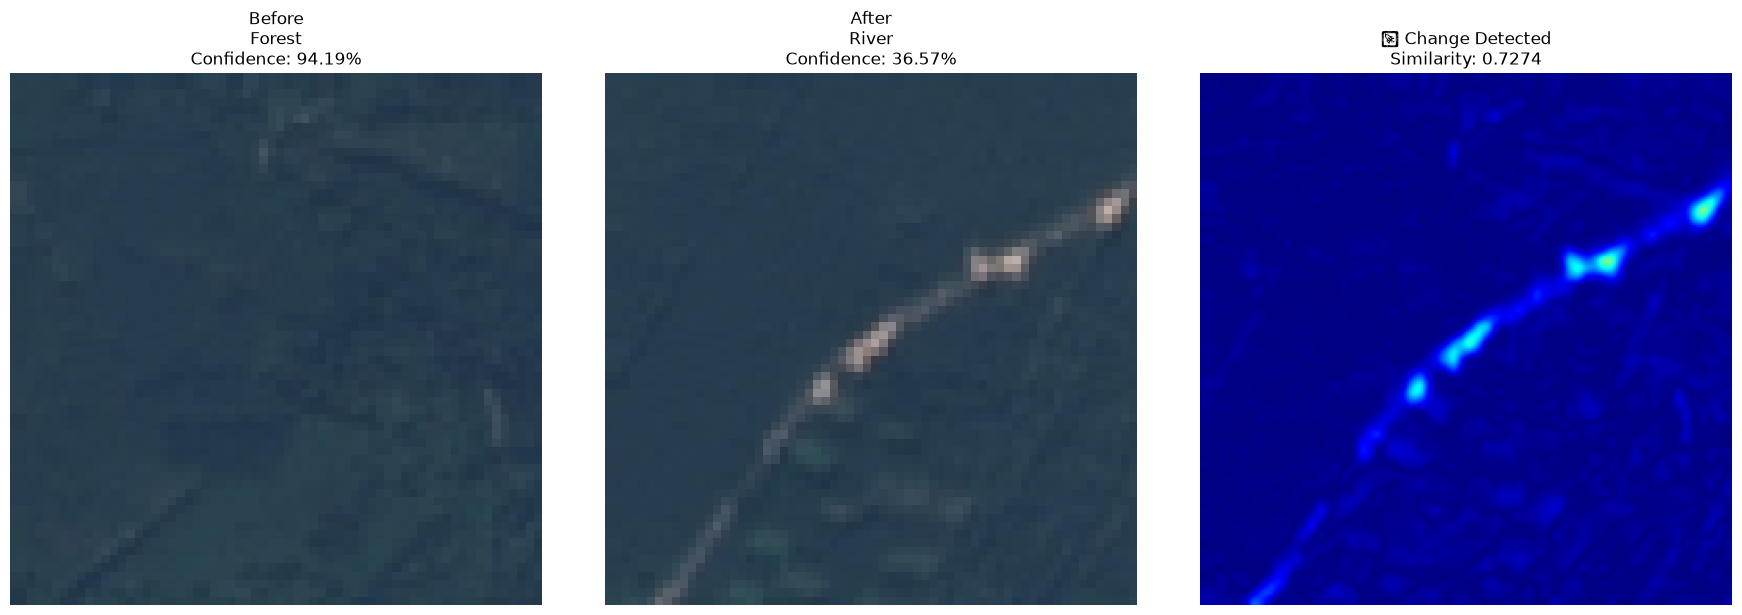

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image1)
axes[0].set_title(
    f"Before\n{class1}\nConfidence: {confidence1:.2%}"
)
axes[0].axis("off")

axes[1].imshow(image2)
axes[1].set_title(
    f"After\n{class2}\nConfidence: {confidence2:.2%}"
)
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
axes[2].set_title(
    f"{status}\nSimilarity: {similarity:.4f}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()